In [1]:
import subprocess, sys

packages = [
    "transformers==4.51.3",
    "bitsandbytes>=0.42.0",
    "accelerate>=0.27.0",
    "datasets", "scikit-learn", "seaborn", "matplotlib", "pandas", "numpy",
]
print("Installing packages...")
for pkg in packages:
    result = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                            capture_output=True, text=True)
    print(f"  {pkg:35s} {'OK' if result.returncode == 0 else 'FAILED'}")

print("\nRestarting kernel...")
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

Installing packages...
  transformers==4.51.3                OK
  bitsandbytes>=0.42.0                OK
  accelerate>=0.27.0                  OK
  datasets                            OK
  scikit-learn                        OK
  seaborn                             OK
  matplotlib                          OK
  pandas                              OK
  numpy                               OK

Restarting kernel...


{'status': 'ok', 'restart': True}

In [1]:
# ── Auth FIRST (token survives after restart here, not in Cell 1) ─────────────
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login
login(token=UserSecretsClient().get_secret("HF_TOKEN"))
print("✓ HF login successful")

import os, json, torch, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
warnings.filterwarnings("ignore")

MODEL_NAME  = "meta-llama/Meta-Llama-3.1-8B-Instruct"
THINKING_ON = True
BATCH_SIZE  = 1
MAX_NEW_TOK = 512 if THINKING_ON else 8
MAX_CTX_LEN = 2048
LABEL_NAMES = [
    "No Defense", "Action", "Major Image-Dist.", "Disavowal",
    "Minor Image-Dist.", "Neurotic", "Obsessional", "High-Adaptive", "Needs More Info",
]
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Model: {MODEL_NAME}  |  Thinking: {THINKING_ON}")

✓ HF login successful
GPU: Tesla T4
VRAM: 15.6 GB
Model: meta-llama/Meta-Llama-3.1-8B-Instruct  |  Thinking: True


In [2]:
# ── Cell 3: System prompt (aligned with paper's DMRS framework) ───────────────
# The paper uses DMRS levels, descriptive items, and a four-stage reasoning
# approach (stressor → screening → validation → synthesis).
# In zero-shot, we replicate this by embedding the full DMRS taxonomy and
# asking the model to reason through the same stages before answering.

SYSTEM_PROMPT = """You are an expert clinical psychologist specializing in the Defense Mechanism Rating Scales (DMRS). Your task is to analyze a seeker's utterance in a supportive conversation and classify its psychological defense level.

## DMRS Defense Level Taxonomy

**Level 0 — No Defense**
Mechanisms: N/A
Definition: Purely functional utterances that maintain conversational flow without engaging psychological conflict. Includes greetings, phatic expressions, simple acknowledgments, logistical exchanges.
Example: "Hello", "Thank you", "Okay", simple yes/no responses.

**Level 1 — Action Defenses**
Mechanisms: Passive Aggression, Help-Rejecting Complaining, Acting Out
Definition: Dealing with internal conflicts by acting on the environment impulsively without reflection. Distress is channeled into behavior to release tension, gratify wishes, or avoid painful feelings.
Example: Venting frustration through complaints that reject any offered help; picking fights as a way to discharge anxiety.

**Level 2 — Major Image-Distorting Defenses**
Mechanisms: Splitting (self-image and others' image), Projective Identification
Definition: Coping with intolerable anxiety by grossly distorting the image of oneself or others into all-good or all-bad poles. Simplifies reality to avoid the anxiety of ambivalence.
Example: "My boss is completely incompetent and ruining everything" or "My new partner is perfect and will solve all my problems."

**Level 3 — Disavowal Defenses**
Mechanisms: Denial, Rationalization, Projection, Autistic Fantasy
Definition: Dealing with stressors by refusing to acknowledge unacceptable aspects of reality. Justifies not taking responsibility by denying problems, providing excuses, attributing blame to others, or retreating into fantasy.
Example: "I didn't get the promotion because my boss is biased, not because of my performance."

**Level 4 — Minor Image-Distorting Defenses**
Mechanisms: Devaluation (self/other), Idealization (self/other), Omnipotence
Definition: Protecting self-esteem by distorting one's image in a less severe manner than Level 2. Temporarily boosts or deflates self-esteem by attributing exaggerated qualities to self or others.
Example: "Sure they succeeded, but it was just luck. Anyone could have done it."

**Level 5 — Neurotic Defenses**
Mechanisms: Repression, Dissociation, Reaction Formation, Displacement
Definition: Managing emotional conflict by keeping unacceptable wishes or motives out of conscious awareness. Feelings surface indirectly or are displaced onto unrelated targets.
Example: Feeling irritable and anxious all day, only to realize later it is the anniversary of a painful event.

**Level 6 — Obsessional Defenses**
Mechanisms: Isolation of Affect, Intellectualization, Undoing
Definition: Managing threatening feelings by separating them from thoughts or events. The individual remains cognitively aware but avoids emotional impact using excessive logic, abstract thinking, or symbolic acts.
Example: Describing a traumatic accident with precise technical detail and no emotion, as if reading a report.

**Level 7 — High-Adaptive Defenses**
Mechanisms: Affiliation, Altruism, Anticipation, Humor, Self-Assertion, Self-Observation, Sublimation, Suppression
Definition: The most adaptive and constructive ways of handling stressors. The individual consciously integrates feelings with thoughts, anticipates challenges, seeks support, and channels emotions productively.
Example: "I am feeling overwhelmed. I will call a colleague to talk through strategies and get a fresh perspective."

**Level 8 — Needs More Information**
Mechanisms: N/A
Definition: The utterance is too ambiguous or the dialogue context is insufficient to assign a defense level reliably.
Example: A vague "maybe" in response to a deep emotional question where intent cannot be determined.

## Annotation Rules (from the DMRS handbook)
- Judge function with respect to the preceding dialogue context, not surface form.
- Ask: what does this utterance ACHIEVE for the speaker in relation to stress or conflict?
- Pure feeling statements are NOT defenses unless there is clear avoidance, distortion, or transformation.
- Mark adaptive responses (Level 7) when supported by local evidence.
- When two signals compete, prefer the lower maturity level or Level 8 if evidence is insufficient.
- Simple thanks, greetings, and farewells are Level 0.
- Intellectual or analytic language is Level 6 only if it is used to keep feelings at a distance.

## Your Task
Analyze the TARGET utterance in the conversation below.

Reasoning steps (think through these before answering):
1. STRESSOR: What is the psychological stressor or conflict the speaker faces?
2. FUNCTION: What does the target utterance achieve for the speaker — avoidance, distortion, action, adaptation?
3. MECHANISMS: Which specific DMRS mechanisms are present?
4. LEVEL: Which defense level best captures the dominant function?

After reasoning, output your final answer as:
ANSWER: <single digit 0-8>

The ANSWER line must appear at the end and contain only one digit."""


def build_prompt(sample):
    """Build conversation context with [TARGET] marker on the final seeker turn."""
    dialogue     = sample["dialogue"]
    context_lines = []
    for i, turn in enumerate(dialogue):
        speaker = turn["speaker"].capitalize()
        text    = turn["text"].strip()
        is_last = (i == len(dialogue) - 1)
        if is_last and turn["speaker"] == "seeker":
            context_lines.append(f"{speaker} [TARGET]: {text}")
        else:
            context_lines.append(f"{speaker}: {text}")

    context_str = "\n".join(context_lines)
    user_msg = f"Conversation:\n{context_str}\n\nClassify the defense level of the [TARGET] utterance."
    return user_msg

In [3]:
# ── Cell 4: Load data ─────────────────────────────────────────────────────────
# Upload your train.json and test.json to Kaggle via:
# Notebook → Add Data → Upload → select files
# They will appear at /kaggle/input/your-dataset-name/

# Auto-detect data path
DATA_PATHS = [
    "/kaggle/input",
    "./data",
    "."
]

def find_file(filename):
    for base in DATA_PATHS:
        for root, dirs, files in os.walk(base):
            if filename in files:
                path = os.path.join(root, filename)
                print(f"Found {filename} at {path}")
                return path
    raise FileNotFoundError(f"{filename} not found. Upload it to Kaggle input.")

train_path = find_file("train.json")
test_path  = find_file("test.json")

with open(train_path) as f: train_data = json.load(f)
with open(test_path)  as f: test_data  = json.load(f)

print(f"\nTrain samples : {len(train_data)}")
print(f"Test  samples : {len(test_data)}")

# Label distribution
from collections import Counter
label_counts = Counter(s["label"] for s in train_data)
print("\nLabel distribution (train):")
for k in sorted(label_counts):
    print(f"  Level {k} ({LABEL_NAMES[k]:22s}): {label_counts[k]:4d}  ({label_counts[k]/len(train_data)*100:.1f}%)")


Found train.json at /kaggle/input/datasets/mdhralif/psydef-dataset/train.json
Found test.json at /kaggle/input/datasets/mdhralif/psydef-dataset/test.json

Train samples : 1864
Test  samples : 472

Label distribution (train):
  Level 0 (No Defense            ):  296  (15.9%)
  Level 1 (Action                ):  108  (5.8%)
  Level 2 (Major Image-Dist.     ):   61  (3.3%)
  Level 3 (Disavowal             ):   99  (5.3%)
  Level 4 (Minor Image-Dist.     ):   84  (4.5%)
  Level 5 (Neurotic              ):   48  (2.6%)
  Level 6 (Obsessional           ):  172  (9.2%)
  Level 7 (High-Adaptive         ):  968  (51.9%)
  Level 8 (Needs More Info       ):   28  (1.5%)


In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading model (~3-5 min)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
)
model.eval()
print(f"✓ Model loaded!")
print(f"VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

GPU: Tesla T4
VRAM: 15.6 GB
Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loading model (~3-5 min)...


...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

✓ Model loaded!
VRAM used: 1.95 GB


In [6]:
# ── Cell 6: Inference function ────────────────────────────────────────────────
def extract_label_from_output(text):
    """
    Parse the predicted label from model output.
    The model is instructed to end with: ANSWER: <digit>
    Falls back to scanning for any digit 0-8 if the format is not followed.
    """
    # Primary: look for ANSWER: X pattern
    import re
    # Try "ANSWER: X" pattern first
    match = re.search(r'ANSWER\s*:\s*([0-8])', text, re.IGNORECASE)
    if match:
        return int(match.group(1))

    # Secondary: find last standalone digit 0-8 in the text
    digits = re.findall(r'\b([0-8])\b', text)
    if digits:
        return int(digits[-1])

    # Tertiary: any digit character 0-8
    for ch in reversed(text):
        if ch in '012345678':
            return int(ch)

    # Fallback: most common class per paper (High-Adaptive)
    print(f"  Warning: could not parse label from: '{text[-100:]}'")
    return 7


def predict_single(sample, thinking=THINKING_ON):
    """
    Run inference on a single sample using Qwen3's chat template.
    Qwen3 supports thinking mode via enable_thinking=True in apply_chat_template.
    """
    user_content = build_prompt(sample)

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]

    # Qwen3 chat template with thinking mode toggle
    # This matches the paper's (w/) setting for Qwen3-Next
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=thinking,      # w/ = True, w/o = False
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_CTX_LEN,
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOK,
            do_sample=False,              # greedy — matches paper default
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the generated portion
    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    raw_output    = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    label = extract_label_from_output(raw_output)
    return label, raw_output

In [7]:
# ── Cell 7: Quick sanity check on 3 examples ─────────────────────────────────
print("Sanity check on 3 training samples...\n")
for sample in train_data[:3]:
    pred, raw = predict_single(sample)
    true_label = sample["label"]
    status = "✓" if pred == true_label else "✗"
    print(f"  ID: {sample['id']}")
    print(f"  True: {true_label} ({LABEL_NAMES[true_label]})")
    print(f"  Pred: {pred} ({LABEL_NAMES[pred]})  {status}")
    print(f"  Raw output (last 200 chars): ...{raw[-200:]}")
    print()



Sanity check on 3 training samples...

  ID: train_00001
  True: 0 (No Defense)
  Pred: 0 (No Defense)  ✓
  Raw output (last 200 chars): ...nalysis, the target utterance fits the definition of Level 0 — No Defense, as it is a purely functional utterance that maintains conversational flow without engaging psychological conflict.

ANSWER: 0

  ID: train_00002
  True: 2 (Major Image-Dist.)
  Pred: 2 (Major Image-Dist.)  ✓
  Raw output (last 200 chars): ...el 1 and Level 2 defense mechanisms. However, since Level 2 is a more severe distortion of reality, it takes precedence. Therefore, the defense level of the target utterance is **Level 2**.

ANSWER: 2

  ID: train_00003
  True: 7 (High-Adaptive)
  Pred: 1 (Action)  ✗
  Raw output (last 200 chars): ...ould classify the defense level as Level 1 — Action Defenses. The speaker is not directly addressing their emotional state but is instead focusing on the practical aspects of the situation.

ANSWER: 1



In [8]:
# ── Cell 8: Full evaluation with permanent Kaggle Dataset checkpoint ──────────
import os, json, time, shutil
from kaggle_secrets import UserSecretsClient
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm.notebook import tqdm

# ── Config ────────────────────────────────────────────────────────────────────
secrets = UserSecretsClient()
os.environ["KAGGLE_USERNAME"] = secrets.get_secret("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"]      = secrets.get_secret("KAGGLE_KEY")

KAGGLE_USERNAME  = os.environ["KAGGLE_USERNAME"]
DATASET_NAME     = "psydef-checkpoints"
DATASET_SLUG     = f"{KAGGLE_USERNAME}/{DATASET_NAME}"

# Local staging dir — we write here then push to dataset
LOCAL_STAGE_DIR  = "/kaggle/working/ckpt_stage"
LOCAL_CKPT_FILE  = f"{LOCAL_STAGE_DIR}/eval_train_checkpoint.json"

# ── Config — update this path ─────────────────────────────────────────────────
REMOTE_CKPT_FILE = "/kaggle/input/datasets/mdhralif/psydef-checkpoints/eval_train_checkpoint.json"

SAVE_EVERY = 20   # push to Kaggle dataset every N samples

os.makedirs(LOCAL_STAGE_DIR, exist_ok=True)

# Dataset metadata (needed for every update push)
metadata = {
    "title":    DATASET_NAME,
    "id":       DATASET_SLUG,
    "licenses": [{"name": "CC0-1.0"}]
}
with open(f"{LOCAL_STAGE_DIR}/dataset-metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)


# ── Checkpoint helpers ────────────────────────────────────────────────────────
def load_checkpoint():
    """
    Try to load from:
    1. Local staging dir (if we already wrote this session)
    2. Kaggle dataset mount (from a previous session)
    """
    for path, source in [
        (LOCAL_CKPT_FILE,  "local staging"),
        (REMOTE_CKPT_FILE, "Kaggle dataset"),
    ]:
        if os.path.exists(path):
            with open(path) as f:
                ckpt = json.load(f)
            n = len(ckpt["sample_ids"])
            print(f"Checkpoint loaded from {source}")
            print(f"  Resuming from sample {ckpt['last_index'] + 1} ({n} already done)")
            print(f"  Saved at: {ckpt.get('saved_at', 'unknown')}")

            # Copy remote checkpoint to local stage so we can update it
            if path == REMOTE_CKPT_FILE:
                shutil.copy(path, LOCAL_CKPT_FILE)

            return (
                ckpt["y_true"],
                ckpt["y_pred"],
                ckpt["raw_outputs"],
                ckpt["sample_ids"],
                ckpt["errors"],
                ckpt["last_index"],
            )

    print("No checkpoint found — starting from scratch.")
    return [], [], [], [], [], -1


def save_checkpoint_local(y_true, y_pred, raw_outputs, sample_ids, errors, last_index):
    """Write checkpoint to local staging dir (fast)."""
    ckpt = {
        "last_index":  last_index,
        "y_true":      y_true,
        "y_pred":      y_pred,
        "raw_outputs": raw_outputs,
        "sample_ids":  sample_ids,
        "errors":      errors,
        "saved_at":    time.strftime("%Y-%m-%d %H:%M:%S"),
        "n_done":      len(sample_ids),
        "n_total":     len(train_data),
    }
    tmp = LOCAL_CKPT_FILE + ".tmp"
    with open(tmp, "w") as f:
        json.dump(ckpt, f)
    os.replace(tmp, LOCAL_CKPT_FILE)


def push_to_kaggle_dataset():
    """
    Push local staging dir to Kaggle Dataset.
    This is the permanent, session-safe storage.
    """
    print("  Pushing to Kaggle dataset...", end=" ")
    result = os.popen(
        f"kaggle datasets version -p {LOCAL_STAGE_DIR} "
        f"-m 'checkpoint update' --dir-mode zip 2>&1"
    ).read()
    if "error" in result.lower():
        print(f"PUSH FAILED: {result}")
    else:
        print("done ✓")


# ── Load checkpoint ───────────────────────────────────────────────────────────
y_true, y_pred, raw_outputs, sample_ids, errors, last_done = load_checkpoint()

print(f"\nRunning zero-shot evaluation on TRAIN set...")
print(f"Total   : {len(train_data)}")
print(f"Done    : {len(sample_ids)}")
print(f"Left    : {len(train_data) - len(sample_ids)}\n")

start_time = time.time()

for i, sample in enumerate(tqdm(train_data, desc="Evaluating")):

    # ── Skip already-done samples ─────────────────────────────────────────────
    if i <= last_done:
        continue

    # ── Inference ─────────────────────────────────────────────────────────────
    try:
        pred, raw  = predict_single(sample)
        true_label = sample["label"]
        y_true.append(true_label)
        y_pred.append(pred)
        raw_outputs.append(raw)
        sample_ids.append(sample["id"])

    except Exception as e:
        print(f"\nError on {sample['id']}: {e}")
        errors.append(sample["id"])
        y_true.append(sample["label"])
        y_pred.append(7)
        raw_outputs.append(f"ERROR: {str(e)}")
        sample_ids.append(sample["id"])

    # ── Save locally every N samples, push to Kaggle every 5*N ──────────────
    # Local save  : fast,  every 20 samples  (~every few minutes)
    # Kaggle push : slow,  every 100 samples (~every ~10-15 minutes)
    if (i + 1) % SAVE_EVERY == 0:
        save_checkpoint_local(y_true, y_pred, raw_outputs,
                              sample_ids, errors, i)

    if (i + 1) % (SAVE_EVERY * 5) == 0:
        save_checkpoint_local(y_true, y_pred, raw_outputs,
                              sample_ids, errors, i)
        push_to_kaggle_dataset()

    # ── Running metrics every 50 samples ─────────────────────────────────────
    if (i + 1) % 50 == 0:
        elapsed       = time.time() - start_time
        done_this_run = (i - last_done)
        rate = done_this_run / elapsed if elapsed > 0 else 1
        eta  = (len(train_data) - i - 1) / rate if rate > 0 else 0

        p_r, r_r, f1_r, _ = precision_recall_fscore_support(
            y_true, y_pred,
            labels=list(range(1, 9)),
            average="macro", zero_division=0
        )
        acc_r = accuracy_score(y_true, y_pred) * 100
        print(f"  [{i+1}/{len(train_data)}]  "
              f"ACC: {acc_r:.1f}  F1: {f1_r*100:.1f}  "
              f"ETA: {eta/60:.1f}min")

# ── Final save ────────────────────────────────────────────────────────────────
save_checkpoint_local(y_true, y_pred, raw_outputs,
                      sample_ids, errors, len(train_data) - 1)
push_to_kaggle_dataset()

elapsed_total = time.time() - start_time
print(f"\nCompleted in {elapsed_total/60:.1f} minutes.")
print(f"Errors  : {len(errors)}")
print(f"Saved permanently → kaggle.com/datasets/{DATASET_SLUG}")


Checkpoint loaded from Kaggle dataset
  Resuming from sample 1700 (1700 already done)
  Saved at: 2026-03-30 02:01:38

Running zero-shot evaluation on TRAIN set...
Total   : 1864
Done    : 1700
Left    : 164



Evaluating:   0%|          | 0/1864 [00:00<?, ?it/s]

Supporter: That's great to hear.'
  [1750/1864]  ACC: 30.8  F1: 16.2  ETA: 43.7min
  Pushing to Kaggle dataset... done ✓
  [1800/1864]  ACC: 30.6  F1: 15.9  ETA: 24.9min
Supporter: I am glad to hear that.'
Supporter: I am glad to hear that.'
Supporter: I am glad to hear that.'
Supporter: I am glad to hear that.'
  [1850/1864]  ACC: 30.4  F1: 15.9  ETA: 5.3min
  Pushing to Kaggle dataset... done ✓

Completed in 63.7 minutes.
Errors  : 0
Saved permanently → kaggle.com/datasets/mdhralif/psydef-checkpoints


In [10]:
# ── Cell 9: Compute final metrics (paper-aligned) ─────────────────────────────
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Paper's exact metric definition:
# "macro precision, recall, and F1-scores, evaluated on the positive classes (1-8)"
acc = accuracy_score(y_true, y_pred) * 100
p, r, f1, _ = precision_recall_fscore_support(
    y_true, y_pred,
    labels=list(range(1, 9)),
    average="macro",
    zero_division=0,
)

print("\n" + "="*60)
print("  ZERO-SHOT RESULTS — Llama3.1-8B (thinking=True)")
print("  Paper reference: Qwen3-Next (w/)  →  Table 5")
print("="*60)
print(f"  Accuracy              : {acc:.2f}   (paper: 44.28)")
print(f"  Macro Precision (1-8) : {p*100:.2f}   (paper: 27.23)")
print(f"  Macro Recall    (1-8) : {r*100:.2f}   (paper: 21.58)")
print(f"  Macro F1        (1-8) : {f1*100:.2f}   (paper: 20.68)")
print("="*60)

# Per-class breakdown
print("\nPer-class Report:")
print(classification_report(
    y_true, y_pred,
    labels=list(range(9)),
    target_names=LABEL_NAMES,
    zero_division=0,
))



  ZERO-SHOT RESULTS — Llama3.1-8B (thinking=True)
  Paper reference: Qwen3-Next (w/)  →  Table 5
  Accuracy              : 30.36   (paper: 44.28)
  Macro Precision (1-8) : 19.58   (paper: 27.23)
  Macro Recall    (1-8) : 19.99   (paper: 21.58)
  Macro F1        (1-8) : 15.84   (paper: 20.68)

Per-class Report:
                   precision    recall  f1-score   support

       No Defense       0.41      0.55      0.47       296
           Action       0.08      0.10      0.09       108
Major Image-Dist.       0.09      0.08      0.09        61
        Disavowal       0.11      0.45      0.18        99
Minor Image-Dist.       0.11      0.12      0.11        84
         Neurotic       0.05      0.31      0.09        48
      Obsessional       0.25      0.16      0.20       172
    High-Adaptive       0.78      0.30      0.43       968
  Needs More Info       0.09      0.07      0.08        28

         accuracy                           0.30      1864
        macro avg       0.22      0.

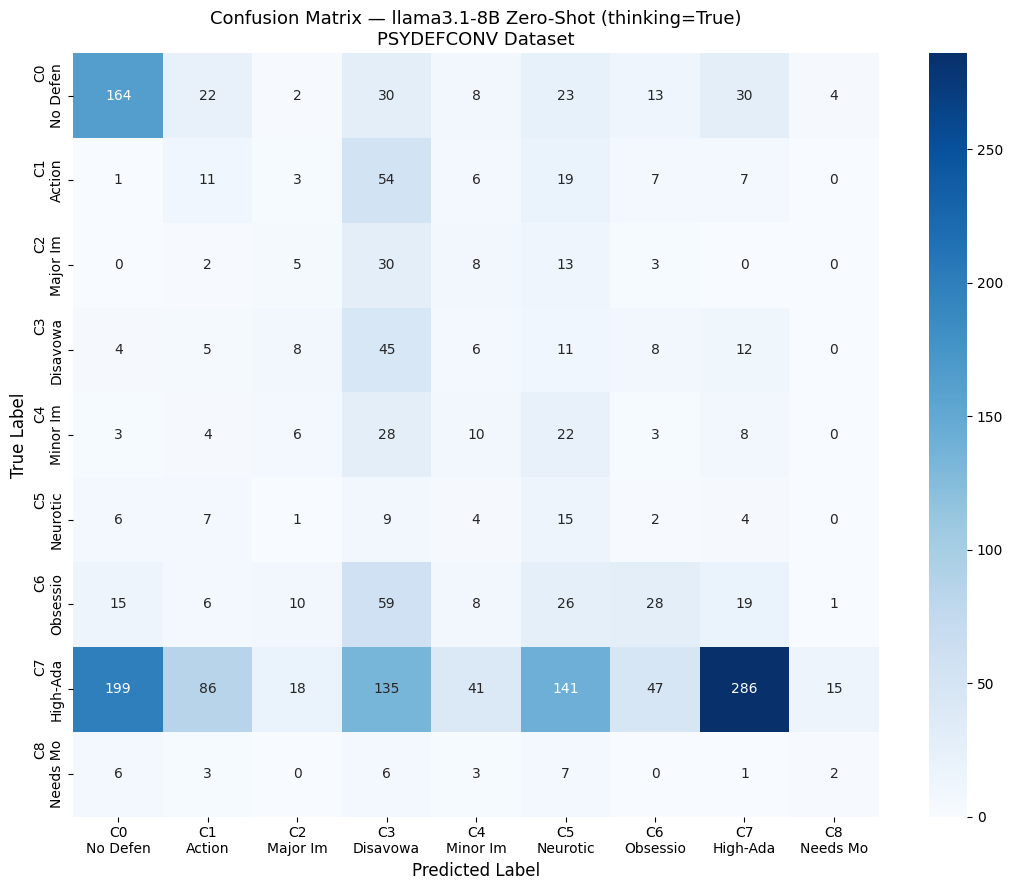

Confusion matrix saved.


In [11]:
# ── Cell 10: Confusion matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=list(range(9)))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"C{i}\n{LABEL_NAMES[i][:8]}" for i in range(9)],
    yticklabels=[f"C{i}\n{LABEL_NAMES[i][:8]}" for i in range(9)],
    ax=ax
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — llama3.1-8B Zero-Shot (thinking=True)\nPSYDEFCONV Dataset", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_llama3.1-8B.png", dpi=150)
plt.show()
print("Confusion matrix saved.")

In [12]:
# ── Cell 11: Error analysis — what the model gets wrong ───────────────────────
# This replicates the paper's finding:
# "models exhibit a strong bias toward predicting the high-adaptive level"

pred_dist = Counter(y_pred.tolist())
true_dist = Counter(y_true.tolist())

print("\nPrediction vs True distribution:")
print(f"{'Level':<8} {'Label':<25} {'True':>6} {'Pred':>6} {'Diff':>6}")
print("-" * 55)
for i in range(9):
    t = true_dist.get(i, 0)
    p_cnt = pred_dist.get(i, 0)
    diff = p_cnt - t
    sign = "+" if diff > 0 else ""
    print(f"  {i:<6} {LABEL_NAMES[i]:<25} {t:>6} {p_cnt:>6} {sign}{diff:>5}")


Prediction vs True distribution:
Level    Label                       True   Pred   Diff
-------------------------------------------------------
  0      No Defense                   296    398 +  102
  1      Action                       108    146 +   38
  2      Major Image-Dist.             61     53    -8
  3      Disavowal                     99    396 +  297
  4      Minor Image-Dist.             84     94 +   10
  5      Neurotic                      48    277 +  229
  6      Obsessional                  172    111   -61
  7      High-Adaptive                968    367  -601
  8      Needs More Info               28     22    -6


In [14]:
# ── Cell 12: Save results ─────────────────────────────────────────────────────
results_df = pd.DataFrame({
    "id":         sample_ids,
    "true_label": y_true.tolist(),
    "pred_label": y_pred.tolist(),
    "correct":    (y_true == y_pred).tolist(),
    "raw_output": raw_outputs,
})
results_df.to_csv("/kaggle/working/eval_results_llama3.1-8B.csv", index=False)

summary = {
    "model":            MODEL_NAME,
    "thinking":         THINKING_ON,
    "n_samples":        len(y_true),
    "accuracy":         round(acc, 2),
    "macro_precision":  round(p * 100, 2),
    "macro_recall":     round(r * 100, 2),
    "macro_f1":         round(f1 * 100, 2),
    "paper_reference":  {"model": "Qwen3-Next (w/)", "acc": 44.28, "f1": 20.68},
    "n_errors":         len(errors),
}
with open("/kaggle/working/summary_llama3.1-8B.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nResults saved:")
print(f"  /kaggle/working/eval_results_llama3.1-8B.csv")
print(f"  /kaggle/working/summary_llama3.1-8B.json")
print(f"  /kaggle/working/confusion_matrix_llama3.1-8B.png")


Results saved:
  /kaggle/working/eval_results_llama3.1-8B.csv
  /kaggle/working/summary_llama3.1-8B.json
  /kaggle/working/confusion_matrix_llama3.1-8B.png


In [15]:
# ── Cell 13: Generate test predictions for submission ─────────────────────────
print("\nGenerating predictions on test set...")

test_predictions = []
for sample in tqdm(test_data, desc="Test inference"):
    try:
        pred, raw = predict_single(sample)
    except Exception as e:
        print(f"Error on {sample['id']}: {e}")
        pred = 7
    test_predictions.append({"id": sample["id"], "label": pred})

with open("/kaggle/working/predictions.json", "w") as f:
    json.dump(test_predictions, f, indent=2)

pred_dist_test = Counter(p["label"] for p in test_predictions)
print(f"\nTest predictions saved → /kaggle/working/predictions.json")
print(f"Total: {len(test_predictions)}")
print("\nTest prediction distribution:")
for k in sorted(pred_dist_test):
    print(f"  Level {k} ({LABEL_NAMES[k]:22s}): {pred_dist_test[k]:4d}  ({pred_dist_test[k]/len(test_predictions)*100:.1f}%)")



Generating predictions on test set...


Test inference:   0%|          | 0/472 [00:00<?, ?it/s]


Test predictions saved → /kaggle/working/predictions.json
Total: 472

Test prediction distribution:
  Level 0 (No Defense            ):   92  (19.5%)
  Level 1 (Action                ):   38  (8.1%)
  Level 2 (Major Image-Dist.     ):   14  (3.0%)
  Level 3 (Disavowal             ):  101  (21.4%)
  Level 4 (Minor Image-Dist.     ):   26  (5.5%)
  Level 5 (Neurotic              ):   83  (17.6%)
  Level 6 (Obsessional           ):   40  (8.5%)
  Level 7 (High-Adaptive         ):   75  (15.9%)
  Level 8 (Needs More Info       ):    3  (0.6%)


In [1]:
# ── Cell: One-time dataset setup ──────────────────────────────────────────────
# Run this ONCE to create the persistent storage dataset on Kaggle
# After running, go to kaggle.com/datasets → you'll see "psydef-checkpoints"

import os, json
from kaggle_secrets import UserSecretsClient

# Get your Kaggle credentials (add these in Notebook → Add-ons → Secrets)
# KAGGLE_USERNAME → your kaggle username
# KAGGLE_KEY      → your kaggle API key (from kaggle.com/settings → API)
secrets = UserSecretsClient()
os.environ["KAGGLE_USERNAME"] = secrets.get_secret("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"]      = secrets.get_secret("KAGGLE_KEY")

KAGGLE_USERNAME  = os.environ["KAGGLE_USERNAME"]
DATASET_NAME     = "psydef-checkpoints"
LOCAL_STAGE_DIR  = "/kaggle/working/ckpt_stage"
os.makedirs(LOCAL_STAGE_DIR, exist_ok=True)

# Create dataset metadata
metadata = {
    "title":    "psydef-checkpoints",
    "id":       f"{KAGGLE_USERNAME}/{DATASET_NAME}",
    "licenses": [{"name": "CC0-1.0"}]
}
with open(f"{LOCAL_STAGE_DIR}/dataset-metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Create a placeholder file so the dataset isn't empty
with open(f"{LOCAL_STAGE_DIR}/README.txt", "w") as f:
    f.write("PsyDef zero-shot evaluation checkpoints.\n")

# Create the dataset on Kaggle
!kaggle datasets create -p {LOCAL_STAGE_DIR} --dir-mode zip

print(f"Dataset created at: kaggle.com/datasets/{KAGGLE_USERNAME}/{DATASET_NAME}")
print("Now add it to this notebook via: Notebook → Add Data → Your Datasets → psydef-checkpoints")
print("It will mount at: /kaggle/input/psydef-checkpoints/")

Starting upload for file README.txt
100%|██████████████████████████████████████████| 41.0/41.0 [00:00<00:00, 111B/s]
Upload successful: README.txt (41B)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/mdhralif/psydef-checkpoints
Dataset created at: kaggle.com/datasets/mdhralif/psydef-checkpoints
Now add it to this notebook via: Notebook → Add Data → Your Datasets → psydef-checkpoints
It will mount at: /kaggle/input/psydef-checkpoints/


In [9]:
# ── Check checkpoint is accessible ───────────────────────────────────────────
import os, json

REMOTE_CKPT_FILE = "/kaggle/input/datasets/ahmedalfeysani/psydef-checkpoints/eval_train_checkpoint.json"

if os.path.exists(REMOTE_CKPT_FILE):
    with open(REMOTE_CKPT_FILE) as f:
        ckpt = json.load(f)
    print(f"Checkpoint found!")
    print(f"  Samples done : {ckpt['n_done']}")
    print(f"  Last index   : {ckpt['last_index']}")
    print(f"  Saved at     : {ckpt['saved_at']}")
    print(f"  Will resume from sample {ckpt['last_index'] + 1}")
else:
    print("NOT FOUND — dataset not attached to notebook yet.")
    print("Go to: Add Data -> Your Datasets -> psydef-checkpoints -> Add")
    print(f"\nFiles in /kaggle/input/:")
    for d in os.listdir("/kaggle/input"):
        print(f"  {d}")

NOT FOUND — dataset not attached to notebook yet.
Go to: Add Data -> Your Datasets -> psydef-checkpoints -> Add

Files in /kaggle/input/:
  datasets
